In [1]:
import os
import sys
import re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import importlib
import seaborn as sns

import catrace.exp_collection as ecl
import catrace.dimensionality_reduction as catdr
import catrace.process_time_trace as ptt 

from os.path import join as pjoin
from catrace.dataset import load_dataset_config

c:\Users\hubob\miniconda3\envs\catrace\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_name = 'juvenile'
window_name = 'time_window_5s'

# dataset_name = 'juvenile_noise_std0p5'
# window_name = 'time_window_3s'

# dataset_name = 'juvenile_dfovf'
# window_name = 'time_window_3s'
config_file = f'../dataset_configs/{dataset_name}_dataset_t7.json'

overwrite = False


from analysis_config import juvenile_window_name_to_frames
window = juvenile_window_name_to_frames[window_name]
print(window_name, window)
window_tag = f'window_{window[0]}to{window[1]}'

import os
fig_dir = f'../../figures_for_paper/{dataset_name}/{window_name}/umap'
os.makedirs(fig_dir, exist_ok=True)

time_window_5s [38, 76]


In [3]:
dsconfig= load_dataset_config(config_file)
umap_dir = pjoin(dsconfig.processed_trace_dir, 'umap', window_tag)
os.makedirs(umap_dir, exist_ok=True)

In [4]:
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['ps.fonttype'] = 42
rcParams['ps.useafm'] = True
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['savefig.dpi'] = 300  # Ensure a high resolution

In [5]:

exp_list = dsconfig.exp_list
trace_dir = dsconfig.processed_trace_dir
in_dir = trace_dir
dff = ecl.concatenate_df_from_db(in_dir, exp_list)
dff = ptt.select_odors_df(dff, dsconfig.odors_stimuli)
dff = ptt.sort_odors(dff, dsconfig.odors_stimuli)
dff = ptt.select_time_points(dff, window)

all_traces_df = dff

2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022-02-13-DpOBEM-N10_Dp None
2022-02-20-DpOBEM-N11_Dp None
2021-02-05-DpOBEM-JH9_Dp None
2021-03-18-DpOBEM-JH10_Dp None
2021-03-19-DpOBEM-JH10_Dp None
2021-04-02-DpOBEM-JH11_Dp None
2021-04-03-DpOBEM-JH11_Dp None
2021-05-01-DpOBEM-JH13_Dp None
2021-05-22-DpOBEM-JH14_Dp None
2021-09-15-DpOBEM-JH20_Dp None
2021-09-17-DpOBEM-JH20_Dp None
2021-09-18-DpOBEM-JH20_Dp None
2021-07-30-DpOBEM-JH17_Dp None
2021-07-31-DpOBEM-JH17_Dp None
2021-09-02-DpOBEM-JH18_Dp None
2021-09-03-DpOBEM-JH18_Dp None
2021-09-04-DpOBEM-JH18_Dp None
2021-09-29-DpOBEM-JH21_Dp None
2021-10-01-DpOBEM-JH21_Dp None
2021-10-02-DpOBEM-JH21_Dp None
2021-10-14-DpOBEM-JH22_Dp None
2021-11-10-DpOBEM-JH23_Dp None
2021-11-11-DpOBEM-JH23_Dp None
2021-11-14-DpOBEM-JH23_Dp None
2021-11-24-DpOBEM-JH24_Dp None
2021-11-27-DpOBEM-JH24_Dp None
2021-11-26-DpOBEM-JH24_Dp None


In [6]:
# Compute UMAP embeddings for each condition
from tqdm import tqdm
importlib.reload(catdr)

umap_params = dict(output_metric='euclidean',
                   n_neighbors=70,
                   min_dist=0.6,
                   n_components=2,
                   random_state=24)
if dataset_name == 'juvenile_dfovf':
    umap_params['n_neighbors'] = 100
    umap_params['min_dist'] = 0.8
    umap_params['random_state'] = 51

if overwrite:
    processed_results = {name: catdr.compute_umap(group, umap_params, scale=False, return_model=True) for name, group in tqdm(dff.groupby(level='condition', axis=1, sort=False))}

    processed_dfs = {name: result[0] for name, result in processed_results.items()}
    umap_models = {name: result[1] for name, result in processed_results.items()}

In [8]:
# Save UMAP models and processed dfs
import pickle
os.makedirs(umap_dir, exist_ok=True)
if overwrite:
    for cond in processed_dfs.keys():
        model_path = pjoin(umap_dir, f'umap_model_{cond}.pkl')
        with open(model_path, 'wb') as f:
            pickle.dump(umap_models[cond], f)
        
        df_path = pjoin(umap_dir, f'umap_processed_df_{cond}.pkl')
        processed_dfs[cond].to_pickle(df_path)

In [10]:
if overwrite:
    # Concatenate all the processed groups back together along columns (axis=1), and add 'cond' level
    latent_df = pd.concat(processed_dfs, axis=1, keys=processed_dfs.keys())
    latent_df.columns.names = ['condition', 'latent_dim']

In [11]:
import cebra.data
import catrace.scale as catsc
importlib.reload(catsc)
# Align the manifolds to naive

if overwrite:
    first_cond_name = 'naive'
    first_cond = latent_df.xs(first_cond_name, level='condition', axis=1)

    aligned_models = dict()
    centering_models = dict()
    aligned_latents = dict()
    labels = np.arange(latent_df.shape[0])
    for cond, subset in latent_df.groupby('condition', axis=1, sort=False):
        if cond == first_cond_name:
            aligned_latents[cond], centering_models[cond] = catsc.centering(subset.droplevel('condition', axis=1), return_model=True)
            aligned_models[cond] = None
        else:
            aligned_models[cond] = cebra.data.helper.OrthogonalProcrustesAlignment()
            aligned = aligned_models[cond].fit_transform(first_cond.to_numpy(), catsc.centering(subset).to_numpy(), labels, labels)
            _, centering_models[cond] = catsc.centering(subset, return_model=True)
            aligned_latents[cond] = catdr.get_embeddf(aligned, subset.index)

    aligned_latent_df = pd.concat(aligned_latents, axis=1, keys=aligned_latents.keys())
    aligned_latent_df.columns.names = ['condition', 'latent_dim']


In [12]:
if overwrite:
    # Save centering models, aligned models and aligned latents
    for cond in aligned_latents.keys():
        centering_model_path = pjoin(umap_dir, f'centering_model_{cond}.pkl')
        if overwrite or not os.path.exists(centering_model_path):
            with open(centering_model_path, 'wb') as f:
                pickle.dump(centering_models[cond], f)

        model_path = pjoin(umap_dir, f'alignment_model_{cond}.pkl')
        if overwrite or not os.path.exists(model_path):
            with open(model_path, 'wb') as f:
                pickle.dump(aligned_models[cond], f)

        latents_path = pjoin(umap_dir, f'aligned_latents_{cond}.pkl')
        if overwrite or not os.path.exists(latents_path):
            with open(latents_path, 'wb') as f:
                pickle.dump(aligned_latents[cond], f)

In [13]:
# Load UMAP models and processed dfs
import pickle
import pandas as pd
umap_models = {}
processed_dfs = {}
for cond in dsconfig.conditions:
    model_path = pjoin(umap_dir, f'umap_model_{cond}.pkl')
    with open(model_path, 'rb') as f:
        umap_models[cond] = pickle.load(f)
    
    df_path = pjoin(umap_dir, f'umap_processed_df_{cond}.pkl')
    processed_dfs[cond] = pd.read_pickle(df_path)

TypeError: Dispatcher._rebuild() got an unexpected keyword argument 'impl_kind'

In [ ]:
# Load aligned models and aligned latents
centering_models = {}
aligned_models = {}
aligned_latents = {}
for cond in dsconfig.conditions:
    centering_model_path = pjoin(umap_dir, f'centering_model_{cond}.pkl')
    with open(centering_model_path, 'rb') as f:
        centering_models[cond] = pickle.load(f)

    model_path = pjoin(umap_dir, f'alignment_model_{cond}.pkl')
    with open(model_path, 'rb') as f:
        aligned_models[cond] = pickle.load(f)
    
    latents_path = pjoin(umap_dir, f'aligned_latents_{cond}.pkl')
    with open(latents_path, 'rb') as f:
        aligned_latents[cond] = pickle.load(f)

aligned_latent_df = pd.concat(aligned_latents, axis=1, keys=aligned_latents.keys())
aligned_latent_df.columns.names = ['condition', 'latent_dim']


In [ ]:
# Plot the four conditions
def plot_conds(df, plot_func, sharex=False,
               sharey=False, figsize=None, ncol=4, *args, **kwargs):
    nrow = 1
    if figsize is None:
        figsize=[4*ncol, 3.5*nrow]
    fig, axes = plt.subplots(nrow, ncol, sharex=sharex,
                             sharey=sharey, figsize=figsize)
    for idx, (name, group) in enumerate(df.groupby(level='condition', axis=1, sort=False)):
        ax = axes.flatten()[idx]
        plot_func(group, *args, **kwargs, ax=ax)
        ax.set_title(name, fontsize=24)

    for ax in axes.flatten():
        ax.tick_params(axis='both', labelsize=20)
    plt.tight_layout()
    return fig, axes

C:\Users\hubob\AppData\Local\Temp\ipykernel_18328\3199819127.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  for idx, (name, group) in enumerate(df.groupby(level='condition', axis=1, sort=False)):
C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\dimensionality_reduction.py:385: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = embeddf.groupby(level=manifold_level)


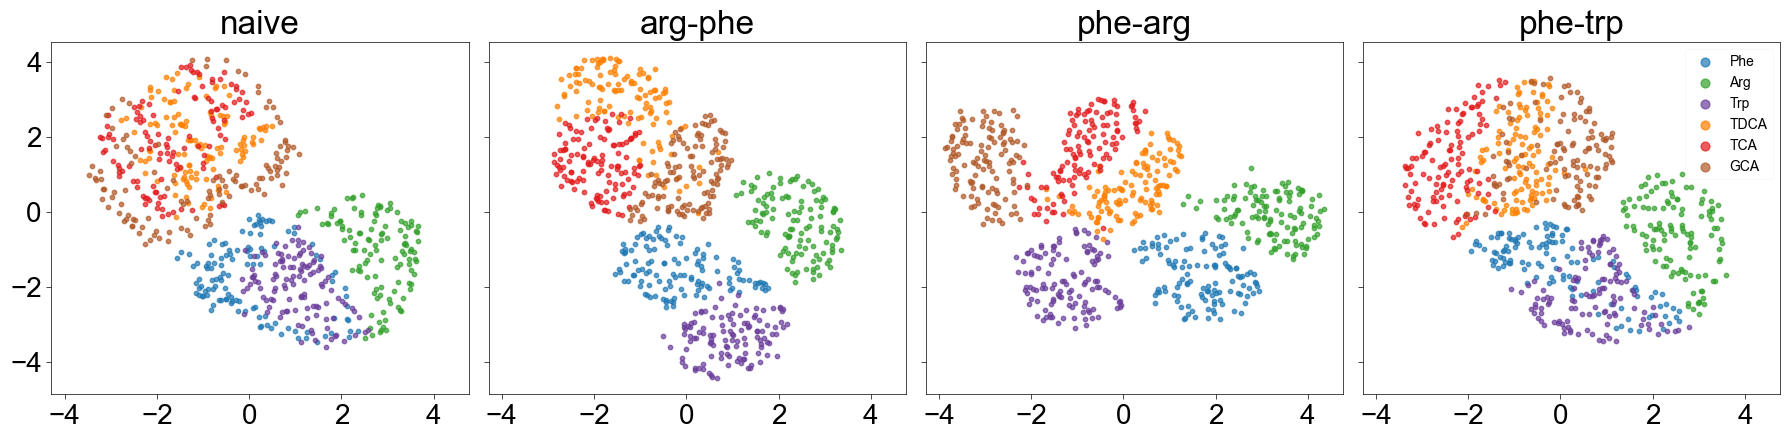

In [ ]:
import catrace.visualize as catvis
importlib.reload(catdr)
component_idx = (0, 1)
clr_cycle = ['#1f78b4', '#33a02c', '#6a3d9a', '#ff7f00', '#e31a1c', '#b15928']
markers = ['o'] * 6
col_idxs = aligned_latent_df.columns.get_level_values('condition').isin(['naive', 'arg-phe', 'phe-arg', 'phe-trp'])
sub_aligned_latent_df = aligned_latent_df.loc[:, col_idxs]
fig, axes = plot_conds(sub_aligned_latent_df, catdr.plot_embed_2d, sharex=True, sharey=True, component_idx=component_idx, manifold_level='odor',
                       clr_cycle=clr_cycle,
                       figsize=(9*2,4.5),
                       ncol=4,
                       markers=markers, marker_size=10,
                       plot_type='scatter')
ax = axes[-1]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::3], labels[::3], framealpha=0.1, markerscale=2)
plt.tight_layout()
#fig.savefig(pjoin(dsconfig.fig_dir, f'{ensemble_name}_umap_aligned_2d.pdf'))

# Get the x and y lim of the plot
xlims = ax.get_xlim()
ylims = ax.get_ylim()

# Save figure
from catrace.for_paper import save_figure_for_paper
save_figure_for_paper(fig, 'umap_aligned', fig_dir)

In [ ]:
sub_aligned_latent_df_frame = sub_aligned_latent_df.copy()
# Rename the last level of the multiindex row to 'frame'
sub_aligned_latent_df_frame.index = sub_aligned_latent_df_frame.index.set_names('frame', level=-1)

In [ ]:
# Save result data to CSV
figure_data_dir = os.path.join('../../publish_dataset/Hu_Temiz_et_al_dataset', 'figure_data')
os.makedirs(figure_data_dir, exist_ok=True)
save_dir = os.path.join(figure_data_dir, 'extended_figure10')
os.makedirs(save_dir, exist_ok=True)


if dataset_name == 'juvenile' and window_name == 'time_window_5s':
    subpanel = 'a'
elif dataset_name == 'juvenile_noise_std0p5' and window_name == 'time_window_3s':
    subpanel = 'b'
elif dataset_name == 'juvenile_dfovf' and window_name == 'time_window_3s':
    subpanel = 'c'
else:
    subpanel = 'unknown'
sub_aligned_latent_df_frame.to_csv(os.path.join(save_dir, f'extended_figure02{subpanel}_umap.csv'))


if subpanel =='a':
    save_dir_2 = os.path.join(figure_data_dir, 'figure02')
    os.makedirs(save_dir_2, exist_ok=True)
    sub_aligned_latent_df_frame.to_csv(os.path.join(save_dir_2, f'figure02d_umap.csv'))

In [ ]:
from catrace.dimensionality_reduction import get_pca_axes_points
conditions = dsconfig.conditions
odors = dsconfig.odors_stimuli

axes_points_dfs = []
for condition in conditions:
    cond_df = all_traces_df.T.xs(condition, level='condition')
    axes_points_list = []
    for odor in odors:
        odor_df = cond_df.T.xs(odor, level='odor').T
        _, axes_points = get_pca_axes_points(odor_df.T)
        axes_points_list.append(axes_points)
    # Concatenate axes points for all odors
    axes_points_df = pd.concat(axes_points_list, keys=odors, names=['odor'])
    axes_points_dfs.append(axes_points_df)

In [ ]:
# Transform axes_points with umap_model and aligned_model
def transform_axes_points(axes_points, umap_model, centering_model, aligned_model):
    umap_axes_points = umap_model.transform(axes_points)
    if centering_model is None:
        centered_points = umap_axes_points
    else:
        centered_points = centering_model.transform(umap_axes_points)
    if aligned_model is None:
        transformed_points = centered_points
    else:
        transformed_points = aligned_model.transform(centered_points)
    transformed_df = pd.DataFrame(transformed_points, index=axes_points.index)
    return transformed_df

transformed_dfs = []
for idx, condition in enumerate(conditions):
    axes_points = axes_points_dfs[idx]
    umap_model = umap_models[condition]
    centering_model = centering_models[condition]
    aligned_model = aligned_models[condition]
    transformed_df = transform_axes_points(axes_points, umap_model, centering_model, aligned_model)
    transformed_dfs.append(transformed_df)

# Concatenate aligned_umap_axes_points for all conditions
transformed_df = pd.concat(transformed_dfs, keys=conditions, names=['condition'], axis=1)
transformed_df


condition                 naive             arg-phe             phe-arg  \
                              0         1         0         1         0   
odor                                                                      
Phe  center           -1.751386 -2.336747 -1.461449 -2.518212  2.790680   
     center_plus_pc1  -0.262221 -3.446347 -1.042646 -2.674765  1.878239   
     center_minus_pc1 -1.808070 -2.097249 -1.794740 -2.056424  2.990361   
     center_plus_pc2  -1.525188 -2.714385 -1.790890 -1.977874  2.881075   
     center_minus_pc2 -1.736469 -2.027089 -1.190224 -2.859931  3.093173   
Arg  center            3.820346  0.185454  2.955472  0.835014  4.655807   
     center_plus_pc1   4.071949 -1.888969  3.793594 -0.738819  3.637778   
     center_minus_pc1  2.687003  0.782267  1.927494  1.646260  4.418603   
     center_plus_pc2   4.113299 -0.106055  2.959346  0.998464  4.752845   
     center_minus_pc2  3.820436 -0.012954  3.309965  0.781953  4.771218   
Trp  center            0.033327 -3.420087  0.071764 -4.589428 -2.725781   
     center_plus_pc1   0.341741 -3.549930  2.033147 -4.304122 -1.786013   
     center_minus_pc1 -0.362470 -3.189271 -0.743449 -3.879117 -2.694275   
     center_plus_pc2  -0.146303 -3.247936 -0.454457 -3.911796 -2.621016   
     center_minus_pc2  0.042291 -3.399957  1.136801 -4.730307 -2.659515   
TDCA center            0.068445  2.093825 -0.216927  3.837417  1.367570   
     center_plus_pc1   0.631360  3.292521 -0.889678  4.319057  1.385486   
     center_minus_pc1 -0.408497  0.989201  0.235400  3.301213  1.473983   
     center_plus_pc2  -2.186474  0.988749  0.062771  3.626618 -0.945120   
     center_minus_pc2  0.999988  2.479193 -3.061920  3.690559  1.464194   
TCA  center           -3.792324  1.570367 -3.094356  0.446150 -1.612553   
     center_plus_pc1  -0.461438  4.189460 -3.353054  1.459195 -0.681599   
     center_minus_pc1 -3.289970  0.482970 -2.833812 -0.037759 -1.477667   
     center_plus_pc2  -3.689583  1.336289 -3.021774  0.261121 -1.686849   
     center_minus_pc2 -2.637011  3.683490 -3.009199  0.274815 -1.358099   
GCA  center           -2.994813 -0.846477  1.510600  1.724016 -4.191876   
     center_plus_pc1   1.366503  2.015223 -2.146950 -0.552012 -4.232162   
     center_minus_pc1 -2.925206 -0.800935  1.476315  1.802706 -3.889731   
     center_plus_pc2  -3.128895 -0.626895  1.495307  1.919830 -4.128322   
     center_minus_pc2  1.253776  1.182633 -2.046249 -0.478276 -3.966829   

condition                         phe-trp            
                              1         0         1  
odor                                                 
Phe  center           -2.641204 -1.813662 -1.946968  
     center_plus_pc1  -3.178581 -1.241429 -2.413639  
     center_minus_pc1 -2.777034 -2.163279 -1.414874  
     center_plus_pc2  -2.804672 -1.437256 -2.216799  
     center_minus_pc2 -2.547924 -1.788633 -2.063122  
Arg  center           -0.819547  2.906731  0.741551  
     center_plus_pc1   1.304807  3.706169 -1.077454  
     center_minus_pc1 -1.427510 -2.085203 -1.746709  
     center_plus_pc2  -0.744944  3.252214  0.752732  
     center_minus_pc2 -0.593810  3.261994  0.306434  
Trp  center           -2.047888 -0.737290 -3.403186  
     center_plus_pc1  -3.269113  0.532417 -3.892638  
     center_minus_pc1 -1.688894 -1.093202 -2.926624  
     center_plus_pc2  -2.301416 -0.364016 -3.560544  
     center_minus_pc2 -1.808946 -0.398935 -3.522408  
TDCA center            0.590886 -3.126029  2.508216  
     center_plus_pc1   1.156291 -1.001354  3.783256  
     center_minus_pc1  1.051942  1.678201  1.988014  
     center_plus_pc2   0.289509 -2.599582 -0.864500  
     center_minus_pc2  1.035167 -3.053948  2.577931  
TCA  center            2.714805 -3.763101  0.750583  
     center_plus_pc1   3.433109 -3.456063  1.963857  
     center_minus_pc1  1.939028 -3.439966 -0.260315  
     center_plus_pc2   1.856448 -3.811597  0.786356  
     center_minus_pc2  3.109247 -3.657665  0.185120  
GCA  center 

In [ ]:
def plot_pc_axes_embed_2d(
    embeddf,
    component_idx,
    ax=None,
    manifold_level='manifold', 
    clr_cycle=None,
):
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.get_figure()

    manifold_names = embeddf.index.unique(manifold_level).tolist()
    if clr_cycle is None:
        clr_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    embeddf = embeddf.iloc[:, list(component_idx)]
    ax.margins(0.05)  # Optional, just adds 5% padding to the autoscaling
    groups = embeddf.groupby(level=manifold_level)
    for name, group in groups:
        cidx = manifold_names.index(name)
        color = clr_cycle[cidx]

        # The row indices within the group are center, center_plus_pc1, center_minus_pc1,
        # center_plus_pc2, center_minus_pc2
        # Get center by row index name
        scaling = 1
        center = group.xs('center', level=1).to_numpy().flatten()
        center_plus_pc1 = group.xs('center_plus_pc1', level=1).to_numpy().flatten() * scaling
        center_minus_pc1 = group.xs('center_minus_pc1', level=1).to_numpy().flatten() * scaling
        center_plus_pc2 = group.xs('center_plus_pc2', level=1).to_numpy().flatten() * scaling
        center_minus_pc2 = group.xs('center_minus_pc2', level=1).to_numpy().flatten() * scaling

        # Plot vectors 
        end_points = [
            center_plus_pc1,
            center_minus_pc1,
            center_plus_pc2,
            center_minus_pc2,
        ]
        for end_point in end_points:
            ax.plot(
                [center[0], end_point[0]],
                [center[1], end_point[1]],
                '-', color=color, linewidth=2
            )
        ax.plot(center[0], center[1], 'o', color=color, markersize=12, markeredgecolor='k', label=name)

        # # Plot a polygon with corners at the end points
        # polygon_points = np.array(end_points + [end_points[0]])
        # ax.plot(polygon_points[:, 0], polygon_points[:, 1], '--', color=color, linewidth=1)
        # # Fill polygon with alpha=0.7
        # ax.fill(polygon_points[:, 0], polygon_points[:, 1], color=color, alpha=0.1)

        # For every pair of end points, plot a polygon with corners at center and each of the pair of end points
        for i in range(len(end_points)):
            for j in range(i+1, len(end_points)):
                pair_points = np.array([center, end_points[i], end_points[j], center])
                ax.plot(pair_points[:, 0], pair_points[:, 1], ':', color=color, linewidth=1)
                ax.fill(pair_points[:, 0], pair_points[:, 1], color=color, alpha=0.05)

    return fig, ax

C:\Users\hubob\AppData\Local\Temp\ipykernel_18328\3199819127.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  for idx, (name, group) in enumerate(df.groupby(level='condition', axis=1, sort=False)):


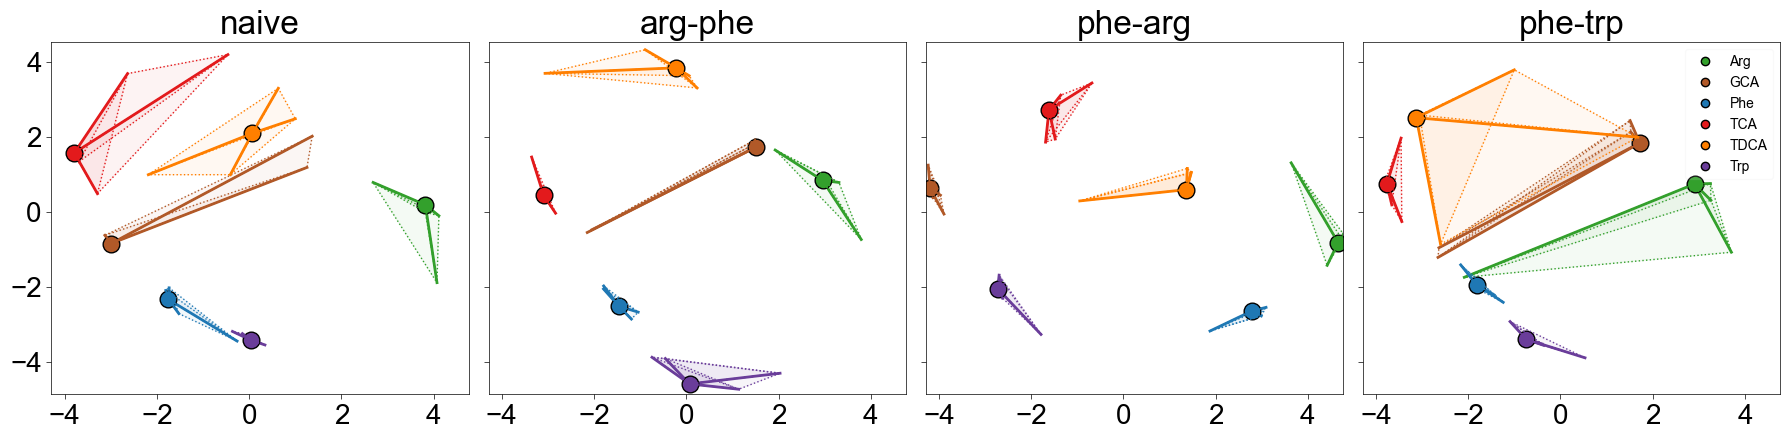

In [ ]:
import catrace.visualize as catvis
importlib.reload(catdr)
component_idx = (0, 1)
clr_cycle = ['#1f78b4', '#33a02c', '#6a3d9a', '#ff7f00', '#e31a1c', '#b15928']
markers = ['o'] * 6
fig, axes = plot_conds(transformed_df, plot_pc_axes_embed_2d, sharex=True, sharey=True, component_idx=component_idx, manifold_level='odor',
                       clr_cycle=clr_cycle,
                       figsize=(9*2,4.5),
                       ncol=4,
)
ax = axes[-1]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, framealpha=0.1, markerscale=0.5)
#fig.savefig(pjoin(dsconfig.fig_dir, f'{ensemble_name}_umap_aligned_2d.pdf'))

# Set the x and y lim of the plot
ax.set_xlim(xlims)
ax.set_ylim(ylims)
plt.tight_layout()

# Save figure as pdf, svg, eps
save_figure_for_paper(fig, 'umap_aligned_with_first2_pca_axes', fig_dir)
